# Task 2B: Spatial Travel Analysis

Geographic patterns, OD flows and spatial differences in travel behaviour.

## 1. Load analysis-ready trips

In [17]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import LineString

root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
output_dir = root / "output"
external_dir = root / "data" / "external"
output_dir.mkdir(exist_ok=True)


data_file = output_dir / "task1_analysis_ready_trips.csv"
if data_file is None:
    raise FileNotFoundError("Run Task 1 first.")

df = pd.read_csv(data_file)

for c in ["Origin eastings", "Origin northings",
          "Destination eastings", "Destination northings",
          "Distance (km)", "Distance category", "Weight_2"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

print(f"Trips: {len(df):,} | Respondents: {df['caseid'].nunique():,}")

Trips: 6,631 | Respondents: 4,097


## 2. Load TfSE boundaries

In [18]:
boundary_files = list(external_dir.glob("*.gpkg"))
if not boundary_files:
    raise FileNotFoundError("Add the ONS Counties and Unitary Authorities boundary GeoPackage to data/external/.")

boundaries = gpd.read_file(boundary_files[0], layer="CTYUA_DEC_2025_UK_BSC").to_crs(27700)

TFSE_LTAS = [
    "West Berkshire", "Reading", "Wokingham", "Bracknell Forest",
    "Windsor and Maidenhead", "Slough", "Kent", "Medway",
    "Hampshire", "Southampton", "Portsmouth", "Isle of Wight",
    "Surrey", "East Sussex", "West Sussex", "Brighton and Hove"
]

tfse = (
    boundaries.loc[boundaries["CTYUA25NM"].isin(TFSE_LTAS),
                   ["CTYUA25CD", "CTYUA25NM", "geometry"]]
    .rename(columns={"CTYUA25CD": "lta_code", "CTYUA25NM": "lta"})
    .reset_index(drop=True)
)

print(f"TfSE LTAs matched: {len(tfse)}/16")

TfSE LTAs matched: 16/16


**Assumption:** Spatial analysis uses British National Grid (EPSG:27700).

In [19]:
# Export Power BI-friendly TfSE LTA boundaries

powerbi_dir = root / "output" / "powerbi"
powerbi_dir.mkdir(parents=True, exist_ok=True)

tfse_map = tfse[["lta", "geometry"]].copy()

# Clean geometry while still in British National Grid
tfse_map["geometry"] = tfse_map.geometry.buffer(0)

# Simplify slightly for Power BI performance
tfse_map["geometry"] = tfse_map.geometry.simplify(
    tolerance=100,
    preserve_topology=True
)

# Convert to WGS84
tfse_map = tfse_map.to_crs(4326)

# Explicit region-key fields for Power BI
tfse_map["name"] = tfse_map["lta"].astype(str).str.strip()
tfse_map["id"] = tfse_map["lta"].astype(str).str.strip()

map_file = powerbi_dir / "tfse_lta_boundaries_powerbi.geojson"
tfse_map.to_file(map_file, driver="GeoJSON")

print(f"Exported: {map_file}")
print(f"Features: {len(tfse_map)}")
print(tfse_map[["lta", "name", "id"]].to_string(index=False))

Exported: c:\Users\nehav\OneDrive\Desktop\NEHA\transport-regional-travel-analysis\output\powerbi\tfse_lta_boundaries_powerbi.geojson
Features: 16
                   lta                   name                     id
                Medway                 Medway                 Medway
      Bracknell Forest       Bracknell Forest       Bracknell Forest
        West Berkshire         West Berkshire         West Berkshire
               Reading                Reading                Reading
                Slough                 Slough                 Slough
Windsor and Maidenhead Windsor and Maidenhead Windsor and Maidenhead
             Wokingham              Wokingham              Wokingham
     Brighton and Hove      Brighton and Hove      Brighton and Hove
            Portsmouth             Portsmouth             Portsmouth
           Southampton            Southampton            Southampton
         Isle of Wight          Isle of Wight          Isle of Wight
           East Sussex    

## 3. Assign origins and destinations to LTAs

In [20]:
valid_od = df[
    df[["Origin eastings", "Origin northings",
        "Destination eastings", "Destination northings"]].notna().all(axis=1)
].copy()

origins = gpd.GeoDataFrame(
    valid_od,
    geometry=gpd.points_from_xy(valid_od["Origin eastings"], valid_od["Origin northings"]),
    crs=27700
)
destinations = gpd.GeoDataFrame(
    valid_od,
    geometry=gpd.points_from_xy(valid_od["Destination eastings"], valid_od["Destination northings"]),
    crs=27700
)

origin_lta = gpd.sjoin(origins, tfse[["lta", "geometry"]], how="left", predicate="within")["lta"]
destination_lta = gpd.sjoin(destinations, tfse[["lta", "geometry"]], how="left", predicate="within")["lta"]

spatial = valid_od.copy()
spatial["origin_lta"] = origin_lta.reindex(spatial.index).fillna("Outside TfSE")
spatial["destination_lta"] = destination_lta.reindex(spatial.index).fillna("Outside TfSE")

print(
    f"Complete OD: {len(spatial):,} | "
    f"Origin in TfSE: {(spatial['origin_lta'] != 'Outside TfSE').sum():,} | "
    f"Destination in TfSE: {(spatial['destination_lta'] != 'Outside TfSE').sum():,}"
)

Complete OD: 6,173 | Origin in TfSE: 5,969 | Destination in TfSE: 5,252


## 4. Geographic scope of travel

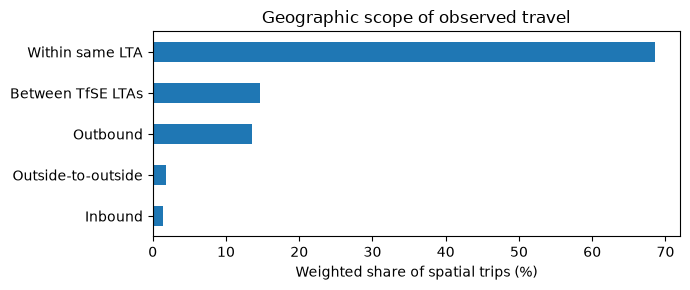

In [21]:
spatial["od_scope"] = np.select(
    [
        (spatial["origin_lta"] != "Outside TfSE") &
        (spatial["destination_lta"] == spatial["origin_lta"]),

        (spatial["origin_lta"] != "Outside TfSE") &
        (spatial["destination_lta"] != "Outside TfSE") &
        (spatial["destination_lta"] != spatial["origin_lta"]),

        (spatial["origin_lta"] != "Outside TfSE") &
        (spatial["destination_lta"] == "Outside TfSE"),

        (spatial["origin_lta"] == "Outside TfSE") &
        (spatial["destination_lta"] != "Outside TfSE")
    ],
    ["Within same LTA", "Between TfSE LTAs", "Outbound", "Inbound"],
    default="Outside-to-outside"
)

scope = spatial.groupby("od_scope")["Weight_2"].sum()
scope = scope / scope.sum() * 100

scope.sort_values().plot.barh(figsize=(7, 3))
plt.xlabel("Weighted share of spatial trips (%)")
plt.ylabel("")
plt.title("Geographic scope of observed travel")
plt.tight_layout()
plt.show()

## 5. OD matrix

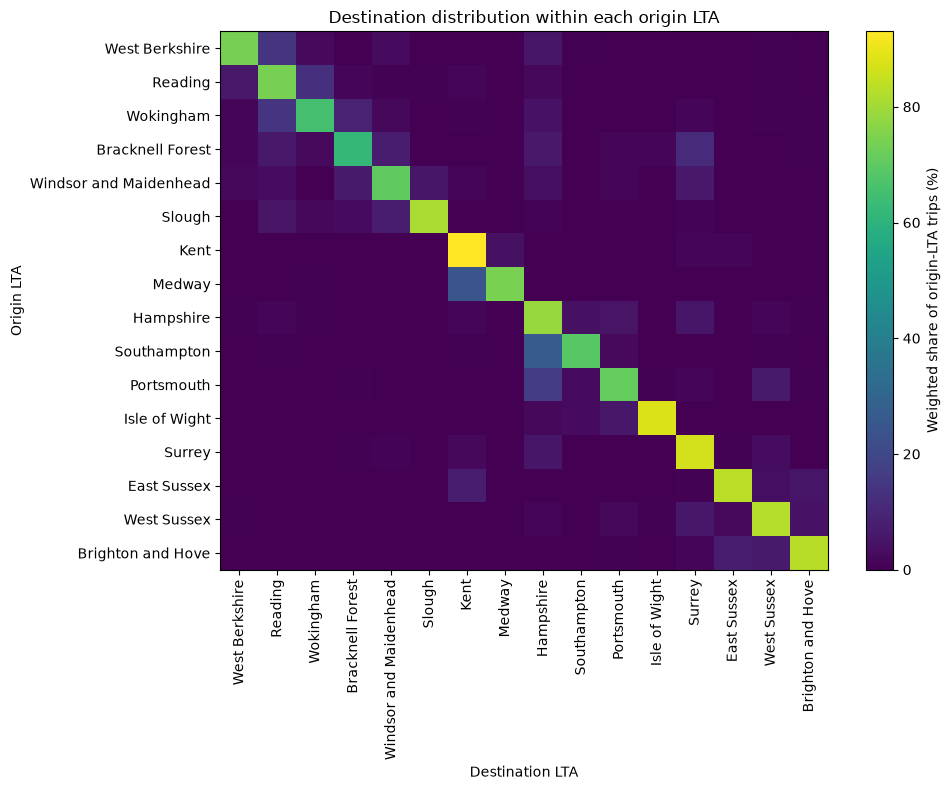

In [22]:
within = spatial[
    (spatial["origin_lta"] != "Outside TfSE") &
    (spatial["destination_lta"] != "Outside TfSE")
].copy()

od = within.pivot_table(
    index="origin_lta", columns="destination_lta",
    values="Weight_2", aggfunc="sum", fill_value=0, observed=False
).reindex(index=TFSE_LTAS, columns=TFSE_LTAS, fill_value=0)

od_pct = od.div(od.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(od_pct.values, aspect="auto")
ax.set_xticks(range(len(od_pct.columns)), od_pct.columns, rotation=90)
ax.set_yticks(range(len(od_pct.index)), od_pct.index)
ax.set_xlabel("Destination LTA")
ax.set_ylabel("Origin LTA")
ax.set_title("Destination distribution within each origin LTA")
fig.colorbar(im, ax=ax, label="Weighted share of origin-LTA trips (%)")
plt.tight_layout()
plt.show()

**Interpretation:** Row-normalisation shows the destination pattern for each origin rather than allowing larger LTAs to dominate the matrix.

## 6. Strongest inter-LTA corridors

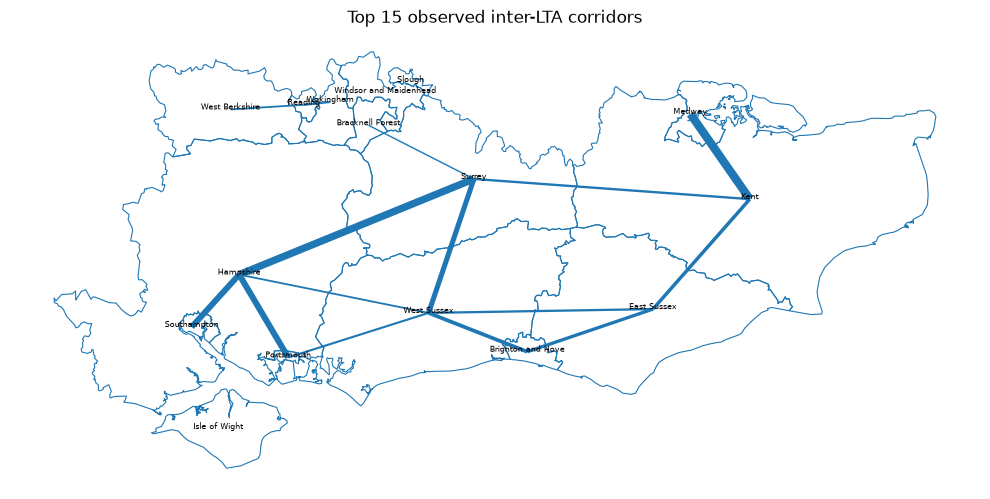

In [23]:
flows = (
    within[within["origin_lta"] != within["destination_lta"]]
    .groupby(["origin_lta", "destination_lta"], observed=False)
    .agg(
        sample_trips=("caseid", "size"),
        weighted_trips=("Weight_2", "sum")
    )
    .reset_index()
)

flows["corridor"] = flows.apply(
    lambda r: " ↔ ".join(sorted([r["origin_lta"], r["destination_lta"]])),
    axis=1
)

corridors = (
    flows.groupby("corridor", observed=False)
    .agg(sample_trips=("sample_trips", "sum"),
         weighted_trips=("weighted_trips", "sum"))
    .reset_index()
    .sort_values("weighted_trips", ascending=False)
)

centres = tfse.copy()
centres["geometry"] = centres.representative_point()
lookup = centres.set_index("lta")["geometry"].to_dict()

top_corridors = corridors.head(15).copy()
top_corridors[["a", "b"]] = top_corridors["corridor"].str.split(" ↔ ", expand=True)
top_corridors["geometry"] = top_corridors.apply(
    lambda r: LineString([lookup[r["a"]], lookup[r["b"]]]), axis=1
)

flow_gdf = gpd.GeoDataFrame(top_corridors, geometry="geometry", crs=27700)
span = flow_gdf["weighted_trips"].max() - flow_gdf["weighted_trips"].min()
width = 2 if span == 0 else 1 + 5 * (
    (flow_gdf["weighted_trips"] - flow_gdf["weighted_trips"].min()) / span
)

fig, ax = plt.subplots(figsize=(10, 8))
tfse.boundary.plot(ax=ax, linewidth=0.8)
flow_gdf.plot(ax=ax, linewidth=width)

for _, r in centres.iterrows():
    ax.annotate(r["lta"], (r.geometry.x, r.geometry.y), fontsize=6, ha="center")

ax.set_title("Top 15 observed inter-LTA corridors")
ax.set_axis_off()
plt.tight_layout()
plt.show()

**Interpretation:** Corridors combine both directions. Lines show observed OD connections, not network routes.

## 7. LTA sample base

In [24]:
origin_region = spatial[
    (spatial["origin_lta"] != "Outside TfSE") &
    spatial["Main mode"].notna()
].copy()

sample = origin_region.groupby("origin_lta").agg(
    trips=("caseid", "size"),
    respondents=("caseid", "nunique")
)

print(
    f"LTAs represented: {len(sample)}/16 | "
    f"Smallest base: {sample['trips'].min()} trips, "
    f"{sample['respondents'].min()} respondents"
)

LTAs represented: 16/16 | Smallest base: 123 trips, 82 respondents


**Assumption:** All 16 LTAs are retained. Raw base sizes accompany exported geographic results and smaller bases are interpreted cautiously.

## 8. Mode share by origin LTA

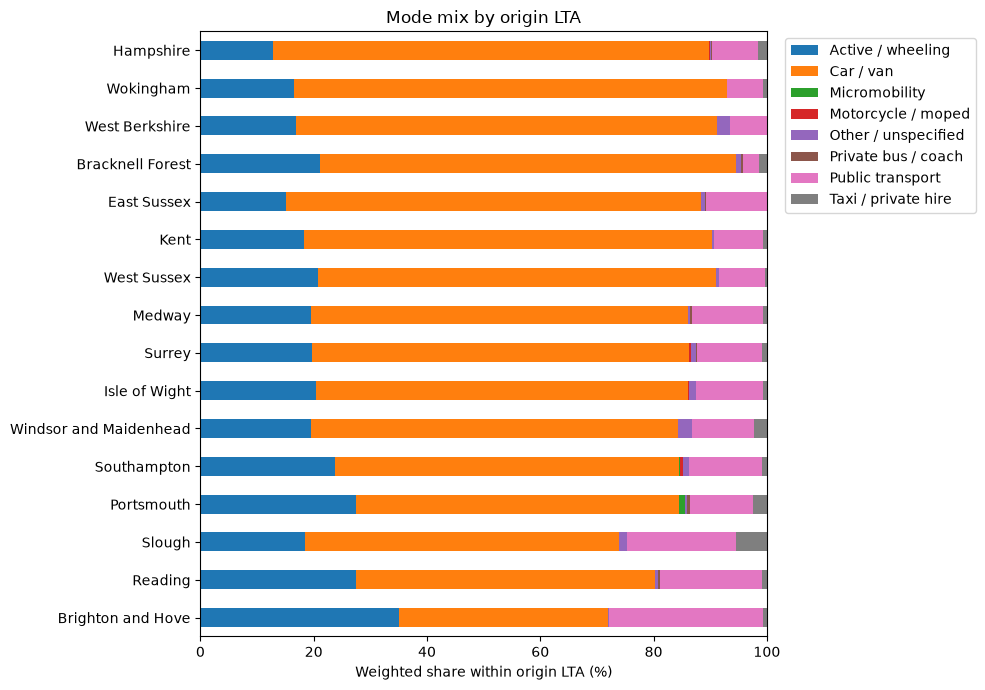

In [25]:
MODE_GROUP = {
    "Car/ van (as the driver)": "Car / van",
    "Car/ van (as a passenger)": "Car / van",
    "Walking": "Active / wheeling",
    "Pedal cycle": "Active / wheeling",
    "Electric cycle (e-bike)": "Active / wheeling",
    "Mobility scooter": "Active / wheeling",
    "Hire e-bike/ e-scooter": "Micromobility",
    "Rail": "Public transport",
    "Public bus service": "Public transport",
    "Other coach (e.g. long distance coaches)": "Public transport",
    "Ferry": "Public transport",
    "Private bus/ coach (e.g. school service, other private service)": "Private bus / coach",
    "Taxi/ minicab": "Taxi / private hire",
    "Motorcycle/ moped": "Motorcycle / moped",
    "Something else": "Other / unspecified"
}

spatial["mode_group"] = spatial["Main mode"].map(MODE_GROUP)
origin_region["mode_group"] = origin_region["Main mode"].map(MODE_GROUP)

mode_lta = origin_region.pivot_table(
    index="origin_lta", columns="mode_group",
    values="Weight_2", aggfunc="sum", fill_value=0, observed=False
)
mode_lta = mode_lta.div(mode_lta.sum(axis=1), axis=0) * 100

order = mode_lta["Car / van"].sort_values().index
mode_lta.loc[order].plot.barh(stacked=True, figsize=(10, 7))
plt.xlabel("Weighted share within origin LTA (%)")
plt.ylabel("")
plt.title("Mode mix by origin LTA")
plt.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 9. Driver vs passenger by origin LTA

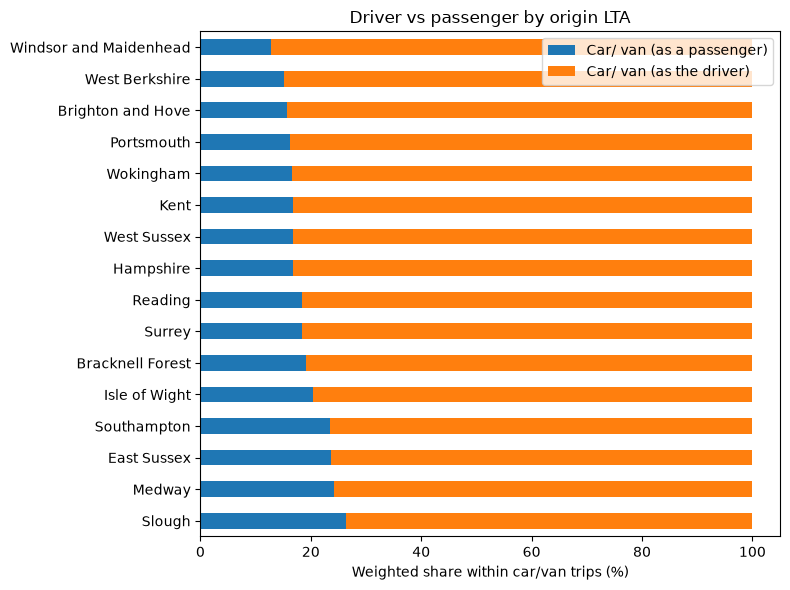

In [26]:
car_modes = ["Car/ van (as the driver)", "Car/ van (as a passenger)"]
car = origin_region[origin_region["Main mode"].isin(car_modes)].copy()

driver_passenger = car.pivot_table(
    index="origin_lta", columns="Main mode",
    values="Weight_2", aggfunc="sum", fill_value=0, observed=False
)
driver_passenger = driver_passenger.div(driver_passenger.sum(axis=1), axis=0) * 100

order = driver_passenger["Car/ van (as the driver)"].sort_values().index
driver_passenger.loc[order].plot.barh(stacked=True, figsize=(8, 6))
plt.xlabel("Weighted share within car/van trips (%)")
plt.ylabel("")
plt.title("Driver vs passenger by origin LTA")
plt.legend(title="")
plt.tight_layout()
plt.show()

**Interpretation:** This separates geographic car dependence from the role of passenger travel.

## 10. Purpose mix by origin LTA

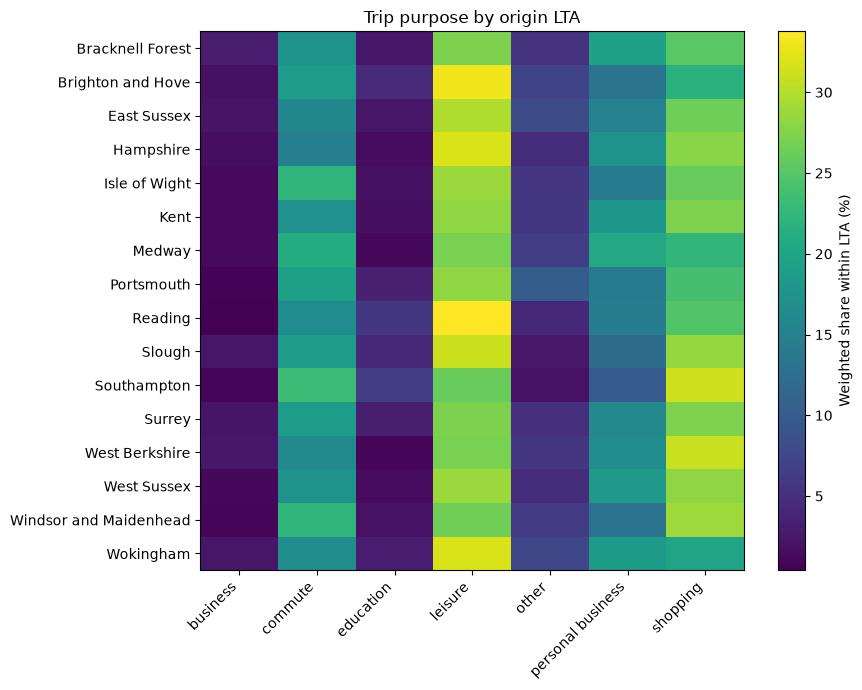

In [27]:
purpose_lta = origin_region.pivot_table(
    index="origin_lta", columns="Purpose_category",
    values="Weight_2", aggfunc="sum", fill_value=0, observed=False
)
purpose_lta = purpose_lta.div(purpose_lta.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(purpose_lta.values, aspect="auto")
ax.set_xticks(range(len(purpose_lta.columns)), purpose_lta.columns, rotation=45, ha="right")
ax.set_yticks(range(len(purpose_lta.index)), purpose_lta.index)
ax.set_title("Trip purpose by origin LTA")
fig.colorbar(im, ax=ax, label="Weighted share within LTA (%)")
plt.tight_layout()
plt.show()

## 11. Distance profile by origin LTA

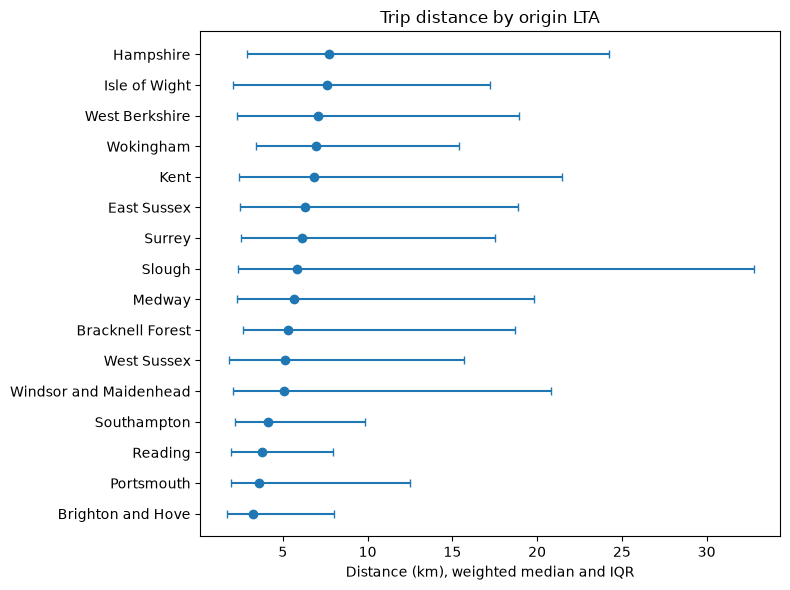

In [28]:
distance_geo = origin_region[
    origin_region["distance_analysis_valid"].astype(str).str.lower().eq("true")
].copy()

def weighted_quantile(values, weights, q=(0.25, 0.50, 0.75)):
    x = pd.DataFrame({"v": values, "w": weights}).dropna()
    x = x[x["w"] > 0].sort_values("v")
    c = x["w"].cumsum() / x["w"].sum()
    return np.interp(q, c, x["v"])

rows = []
for lta, g in distance_geo.groupby("origin_lta"):
    q1, med, q3 = weighted_quantile(g["Distance (km)"], g["Weight_2"])
    rows.append([lta, q1, med, q3])

distance_lta = pd.DataFrame(rows, columns=["LTA", "Q1", "Median", "Q3"]).sort_values("Median")
xerr = np.vstack([
    distance_lta["Median"] - distance_lta["Q1"],
    distance_lta["Q3"] - distance_lta["Median"]
])

plt.figure(figsize=(8, 6))
plt.errorbar(distance_lta["Median"], distance_lta["LTA"], xerr=xerr, fmt="o", capsize=3)
plt.xlabel("Distance (km), weighted median and IQR")
plt.ylabel("")
plt.title("Trip distance by origin LTA")
plt.tight_layout()
plt.show()

## 12. Car dependence and short-car concentration

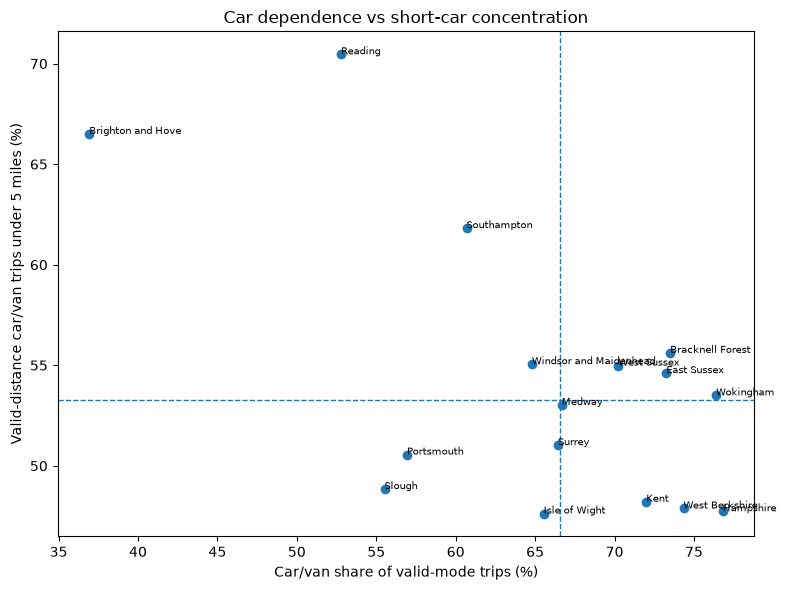

In [29]:
valid_car = car[
    car["distance_analysis_valid"].astype(str).str.lower().eq("true")
].copy()
short_car = valid_car[
    pd.to_numeric(valid_car["Distance category"], errors="coerce").isin([1, 2, 3])
].copy()

all_w = origin_region.groupby("origin_lta")["Weight_2"].sum()
car_w = car.groupby("origin_lta")["Weight_2"].sum()
valid_car_w = valid_car.groupby("origin_lta")["Weight_2"].sum()
short_w = short_car.groupby("origin_lta")["Weight_2"].sum()

car_geo = pd.DataFrame({
    "car_share": car_w / all_w * 100,
    "short_within_valid_car": short_w / valid_car_w * 100,
    "sample_trips": sample["trips"],
    "respondents": sample["respondents"]
}).dropna()

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(car_geo["car_share"], car_geo["short_within_valid_car"])

for lta, r in car_geo.iterrows():
    ax.annotate(lta, (r["car_share"], r["short_within_valid_car"]), fontsize=7)

ax.axvline(car_geo["car_share"].median(), linestyle="--", linewidth=1)
ax.axhline(car_geo["short_within_valid_car"].median(), linestyle="--", linewidth=1)
ax.set_xlabel("Car/van share of valid-mode trips (%)")
ax.set_ylabel("Valid-distance car/van trips under 5 miles (%)")
ax.set_title("Car dependence vs short-car concentration")
plt.tight_layout()
plt.show()

**Interpretation:** High car share and high short-car concentration are separate characteristics and may imply different follow-up questions.

## 13. Purpose of short car trips by LTA

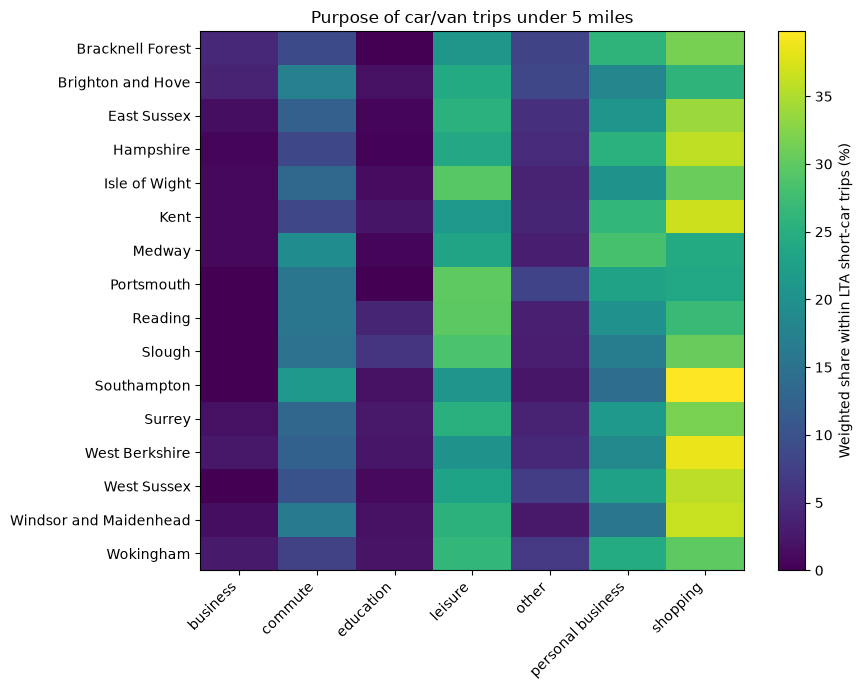

In [30]:
short_purpose_lta = short_car.pivot_table(
    index="origin_lta", columns="Purpose_category",
    values="Weight_2", aggfunc="sum", fill_value=0, observed=False
)
short_purpose_lta = short_purpose_lta.div(short_purpose_lta.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(short_purpose_lta.values, aspect="auto")
ax.set_xticks(range(len(short_purpose_lta.columns)), short_purpose_lta.columns, rotation=45, ha="right")
ax.set_yticks(range(len(short_purpose_lta.index)), short_purpose_lta.index)
ax.set_title("Purpose of car/van trips under 5 miles")
fig.colorbar(im, ax=ax, label="Weighted share within LTA short-car trips (%)")
plt.tight_layout()
plt.show()

**Interpretation:** This distinguishes whether local car dependence is associated mainly with shopping, personal business, commuting or other purposes.

## 14. Mid-distance public transport by geography

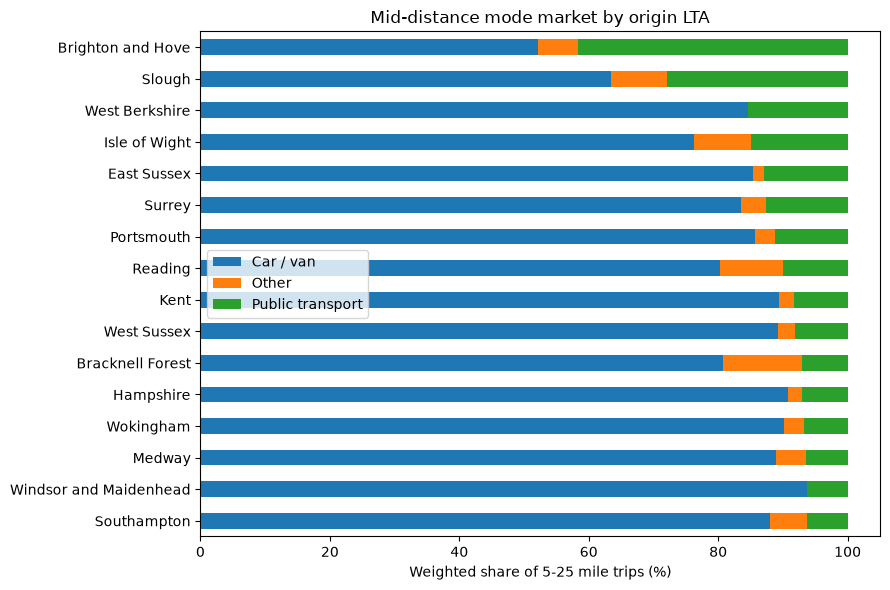

In [31]:
mid = origin_region[
    origin_region["distance_analysis_valid"].astype(str).str.lower().eq("true") &
    pd.to_numeric(origin_region["Distance category"], errors="coerce").isin([4, 5])
].copy()

mid["market"] = np.select(
    [
        mid["Main mode"].isin(car_modes),
        mid["mode_group"].eq("Public transport")
    ],
    ["Car / van", "Public transport"],
    default="Other"
)

mid_mix = mid.pivot_table(
    index="origin_lta", columns="market",
    values="Weight_2", aggfunc="sum", fill_value=0, observed=False
)
mid_mix = mid_mix.div(mid_mix.sum(axis=1), axis=0) * 100

order = mid_mix["Public transport"].sort_values().index
mid_mix.loc[order].plot.barh(stacked=True, figsize=(9, 6))
plt.xlabel("Weighted share of 5-25 mile trips (%)")
plt.ylabel("")
plt.title("Mid-distance mode market by origin LTA")
plt.legend(title="")
plt.tight_layout()
plt.show()

**Interpretation:** This identifies geographic differences in public transport use for 5-25 mile travel; service supply and competitiveness are not observed in the survey.

## 15. Spatial hand-off

In [32]:
spatial.to_csv(output_dir / "task2b_spatial_enriched_trips.csv", index=False)

print("Spatially enriched trip-level dataset saved for downstream analysis.")

Spatially enriched trip-level dataset saved for downstream analysis.
